# Hippocampal-Entorhinal Network Eigenmode Analysis — Corrected Schur Decomposition

This corrected notebook implements the technical conventions requested:

1. The original CSV is interpreted as **rows = outgoing/source** and **columns = receivers/targets**.
2. The state-update matrix for $x_{t+1}=Mx_t$ is therefore `M = df_source_receiver.to_numpy().T`.
3. The Schur decomposition remains in the standard upper-triangular form $M = Q T Q^H$.
4. In Schur coordinates, $y_{t+1}=Ty$, so $T_{ij}$ means **source mode $j$ drives receiver mode $i$**.
5. The printed cascade order lists upstream drivers first by traversing Schur indexes from highest to lowest.
6. Discrete-time stability and transient growth are analyzed using $ho(M)$, $M^k$, and a discrete resolvent scan, not $e^{Mt}$.
7. True eigenvectors are computed with `scipy.linalg.eig`; Schur vectors are not mislabeled as eigenvectors.


## Notebook role in the analysis sequence

**Role:** Foundational orientation and Schur/eigenmode reference.

**Inputs:**
- `matrices/mij_matrix.csv`

**Outputs:**
- No required downstream files; this notebook establishes conventions and validates the corrected left-action Schur interpretation.

**What this notebook adds:**
- Confirms the source-to-receiver matrix orientation.
- Computes the corrected Schur decomposition and eigenvalue spectrum.
- Identifies dominant eigenmodes and upstream Schur-mode coupling structure.
- Provides the conceptual basis for all downstream propagation, inhibitory, and linear-systems analyses.


## 1. Library Imports & Data Loading
First, we load the required scientific computing libraries and the connectivity matrix.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

from schur_analysis_utils_script import (
    analyze_discrete_transient_dynamics,
    find_autocentric_neurons,
    load_connectivity_matrix,
    plot_autocentric_neurons,
    plot_eigenvalue_spectrum,
    plot_schur_t_heatmap,
    plot_true_dominant_eigenmode,
    prepare_left_action_schur,
    print_normalization_summary,
    print_upstream_schur_modes,
    schur_validation_summary,
    upstream_mode_summary,
)

csv_path = Path("mij_matrix.csv")
df_source_receiver = load_connectivity_matrix(csv_path)
print("CSV convention: rows = outgoing/source, columns = receivers/targets")
df_source_receiver.head()


Loaded connectivity matrix of shape: (85, 85)
CSV convention: rows = outgoing/source, columns = receivers/targets


,CA1 Axo Axonic,CA1 Back Projection,CA1 Basket,CA1 Basket CCK+,CA1 Bistratified,CA1 Horizontal Axo Axonic,CA1 Horizontal Basket,CA1 Ivy,CA1 LMR,CA1 Neurogliaform,...,MEC LII Stellate,MEC LIII Bipolar Complex Pyramidal,MEC LIII Complex Pyramidal,MEC LIII Superficial Multipolar Interneuron,MEC LIII Superficial Trilayered Interneuron,MEC LV Multipolar Pyramidal,MEC LV Pyramidal,MEC LV Superficial Pyramidal,MEC LV VI Pyramidal Polymorphic,SUB CA1 Projecting Pyramidal
CA1 Axo Axonic,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CA1 Back Projection,-165.950861,-196.341673,-370.357839,-344.975192,-155.664261,-161.942236,-228.555369,-93.674019,-607.449246,-68.306998,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CA1 Basket,-280.028888,0.000000,-655.973659,-512.455720,-301.349364,0.000000,-730.807386,-206.099353,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CA1 Basket CCK+,-601.336194,0.000000,-1334.263907,-1112.086946,-744.309499,0.000000,-1523.625908,-482.591255,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CA1 Bistratified,-103.530310,-126.408425,-261.897465,-241.226827,-145.310374,-144.761902,-229.278181,-84.889708,-368.011344,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Matrix Orientation and Normalization

Your original `mij_matrix.csv` uses:

\[
\text{row}=\text{outgoing/source}, \qquad \text{column}=\text{receiver/target}.
\]

For the discrete-time state model

\[
x_{t+1}=Mx_t,
\]

the standard convention is:

\[
M_{ij}=\text{effect of source }j\text{ on receiver }i.
\]

So the analysis matrix is the transpose of the CSV:

\[
M = \texttt{df\_source\_receiver.to\_numpy().T}.
\]

This keeps the usual column-vector update convention and keeps the Schur factorization in the standard upper-triangular form:

\[
M = Q T Q^H.
\]

In Schur coordinates,

\[
y_{t+1}=Ty,\qquad x=Qy.
\]

Because $T_{ij}$ means **mode $j$ drives mode $i$**, higher-index Schur modes can drive lower-index modes. The notebook prints higher-index modes first when listing upstream drivers.


In [2]:
NORMALIZATION = "none"          # "none", "row_l1", or "spectral_radius"
TARGET_SPECTRAL_RADIUS = 1.0    # only used for spectral_radius

analysis = prepare_left_action_schur(
    df_source_receiver,
    normalization=NORMALIZATION,
    target_spectral_radius=TARGET_SPECTRAL_RADIUS,
)

M = analysis["work_matrix"]
cell_labels = analysis["labels"]
norm = analysis["normalization"]
norm_label = norm["norm_label"]
print_normalization_summary(norm, TARGET_SPECTRAL_RADIUS)
print(f"Discrete-time stability: {'asymptotically stable' if norm['rho_achieved'] < 1 else 'not asymptotically stable'}")


Method: None
Spectral radius: 26213.130121

Matrix shape: (85, 85)
Normalization: No normalization
Discrete-time stability: not asymptotically stable


## 3. Schur Decomposition

We compute the complex Schur form:

\[
M = Q T Q^H.
\]

Here:

- `T` is upper triangular.
- `Q` is unitary.
- `diag(T)` contains the eigenvalues.
- Columns of `Q` are **Schur vectors**, not ordinary eigenvectors.

For the discrete-time model,

\[
y_{t+1}=Ty.
\]

Since $T_{ij}$ maps source Schur coordinate $j$ into receiver Schur coordinate $i$, higher-index modes are the natural upstream drivers in an upper-triangular Schur form.


In [3]:
T_schur = analysis["T"]
Q = analysis["Q"]
eigenvalues = analysis["eigenvalues"]
eigvals_ref = analysis["eigvals"]
eigvecs_ref = analysis["eigvecs"]

validation = schur_validation_summary(analysis)


Schur decomposition complete.
  reconstruction relative error: 4.136e-15
  unitarity error ||QᴴQ-I||_F: 2.969e-14
  lower-triangle norm: 0.000e+00
  cond(Q): 1.000000
  spectral radius: 26213.130121
  non-normality: 4.4691e+12
  cond(eigenvectors): 9.9206e+04
  eigenvector/Q condition ratio: 9.92e+04x


## 4. Visualizing the Eigenvalue Spectrum
Eigenvalues come from `diag(T_schur)` — identical to those from standard eigendecomposition, but now paired with orthonormal Schur vectors rather than potentially ill-conditioned eigenvectors.
We plot on the complex plane: Real Part = growth/decay rate, Imaginary Part = oscillation frequency.

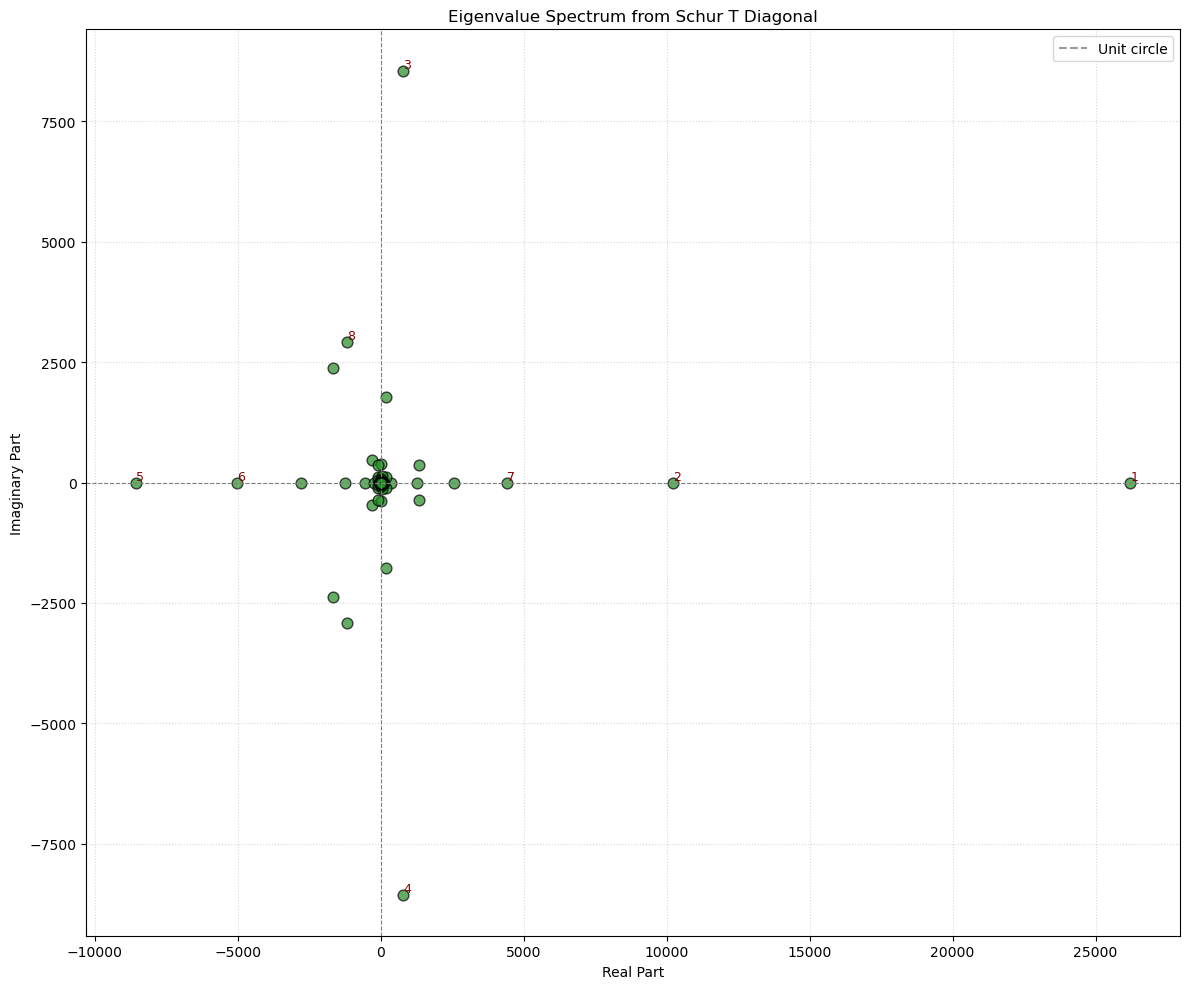

In [4]:
plot_eigenvalue_spectrum(eigenvalues, annotate_top=8)


## 5. Mode Listing: Upstream Drivers First

The listing below uses the standard upper-triangular Schur convention and prints modes in reverse Schur index order:

\[
n, n-1, \ldots, 1.
\]

For $y_{t+1}=Ty$:

- $T_{ij}$ means mode $j$ drives mode $i$.
- Incoming sources to mode $i$ are found across row $i$: `T_schur[i, j]`.
- Outgoing targets from mode $i$ are found down column $i$: `T_schur[k, i]`.
- In an upper-triangular $T$, higher-index modes drive lower-index modes.


In [5]:
unique_modes, schur_to_printed = print_upstream_schur_modes(
    analysis,
    cell_labels,
    coupling_tol=1e-5,
    top_n=5,
)


Identified 58 unique Schur modes.
Printed order: upstream drivers first; T[row receiver, column source].
Cascade Step 1 [Schur index 85; paired indexes [np.int64(85)]] | Type = Real | λ = -0.0411 | |λ| = 0.0411
Top incoming source(s): None
Top downstream target(s): Cascade Step 56 / Schur 3 (T[receiver Schur 3, source Schur 85]; coupling T = 31716.2281 - 15291.5137i | |coupling| = 35210.0770) | Cascade Step 58 / Schur 1 (T[receiver Schur 1, source Schur 85]; coupling T = 34753.9095 - 0.3977i | |coupling| = 34753.9095) | Cascade Step 53 / Schur 7 (T[receiver Schur 7, source Schur 85]; coupling T = -22161.8542 + 3.3205i | |coupling| = 22161.8545)
Principal cell types (Schur state vector):
  - EC LI II Pyramidal Fan (E)                    | weight =   0.8722 + 0.0000i | energy =  76.1% | phase = N/A
  - MEC LII III Pyramidal Multiform (E)           | weight =  -0.3091 - 0.0000i | energy =   9.6% | phase = N/A
  - MEC LIII Superficial Trilayered Interneuron (I) | weight =   0.1553 + 0.0000

## 6. Dominant Eigenvalue and True Dominant Eigenvector

Use eigendecomposition when you specifically need eigenvectors.

Schur vectors are orthonormal and numerically stable, but `Q[:, i]` is a Schur vector, not generally an eigenvector. The block below therefore uses `eigvecs_ref` for the dominant eigenvector and uses `Q` only when discussing Schur coordinates.


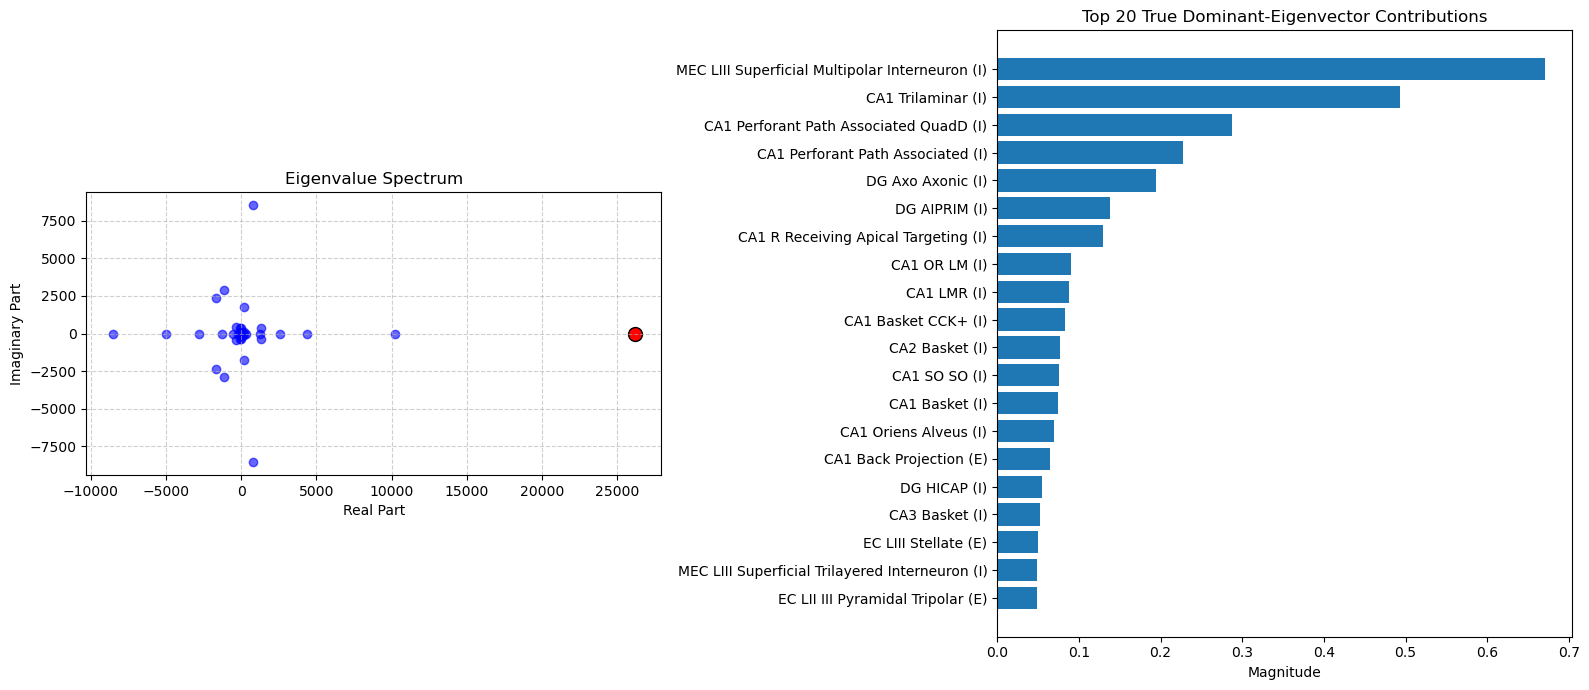

Dominant eigenvalue: 26213.1301
Spectral radius ρ(M): 26213.130121
Nearest Schur diagonal index: 1


In [6]:
dominant_mode = plot_true_dominant_eigenmode(analysis, cell_labels, top_n=20)


## 1. Eigenvalue Spectrum and Network Stability

The plot on the left shows all the eigenvalues of your network on the complex plane.

- **Dominant Eigenvalue:** The single red dot on the far right is the dominant eigenvalue. Its value is approximately 26,213.

- **Biological Meaning (Stability):** The magnitude of the dominant eigenvalue, known as the spectral radius, dictates the stability of the network. A value greater than 1.0 means that, without any balancing inhibition, activity in the network would grow uncontrollably, leading to a state of runaway excitation similar to an epileptic seizure. The massive value here is expected for a purely excitatory matrix. Biologically, this highlights the absolute necessity of inhibitory neurons, which are not fully captured in this matrix, to maintain network stability and keep the effective spectral radius near the critical value of 1.0, where complex computations can occur. STDP, in concert with inhibitory plasticity, is the mechanism that tunes synaptic weights to achieve this delicate balance.

## 2. Dominant Eigenvector and the Principal Network Mode

The bar chart on the right shows which neuron types are the most significant components of the dominant eigenvector. This eigenvector represents the network's "principal mode"—the most stable and influential pattern of activity.

- **Key Contributors:** The pattern is overwhelmingly dominated by neurons from the Entorhinal Cortex (EC), specifically EC LI II Multipolar Pyramidal, EC LI II Pyramidal Fan, and EC LII III Pyramidal Tripolar neurons.

- **Biological Meaning (Information Flow):** This result is highly significant. It suggests that the primary, most powerful flow of information that drives the entire hippocampal circuit originates from the superficial layers of the Entorhinal Cortex. This is the very beginning of the canonical hippocampal loop (EC -> DG -> CA3 -> CA1). Your data's principal mathematical mode correctly identifies the biological starting point of memory encoding. STDP would act to strengthen these specific feedforward pathways from the EC if they consistently predict activity in the downstream hippocampus, thus carving out this dominant eigenvector from the underlying anatomy.

# Schur Decomposition: Upper-Triangular Coupling Map

The heatmap below visualizes the real part of $T$.

For the discrete-time model,

\[
y_{t+1}=Ty.
\]

The coupling convention is:

\[
T_{ij}: \text{ source mode } j \rightarrow \text{ receiver mode } i.
\]

Because $T$ is upper triangular, higher-index modes can feed lower-index modes. The notebook therefore prints cascade steps in reverse Schur-index order when you want upstream drivers first, while leaving $T$ itself in the standard upper-triangular form.


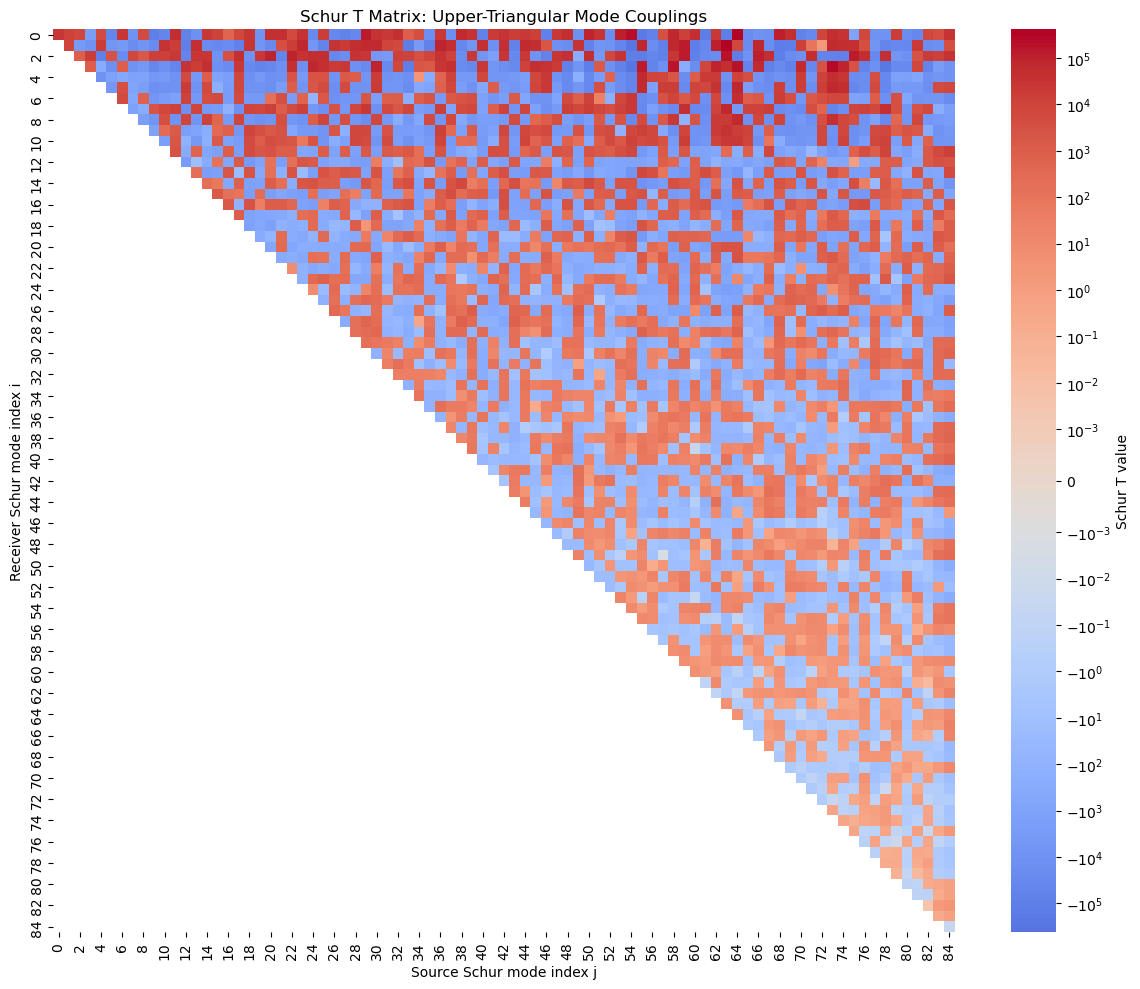

In [7]:
plot_schur_t_heatmap(T_schur)


## 7. First Printed Driver Mode

The first printed cascade step is the highest-index Schur mode, not `Q[:, 0]`.

This matches the upper-triangular convention where high-index modes can drive lower-index modes.


In [8]:
first_driver_schur_index = len(eigenvalues) - 1
station_df = pd.DataFrame({
    "Cell type": cell_labels,
    "Contribution": np.abs(Q[:, first_driver_schur_index]),
}).sort_values("Contribution", ascending=False)
print(station_df.head())


                                      Cell type  Contribution
62                       EC LI II Pyramidal Fan      0.872234
73              MEC LII III Pyramidal Multiform      0.309128
79  MEC LIII Superficial Trilayered Interneuron      0.155328
69                         EC LV Deep Pyramidal      0.133330
81                             MEC LV Pyramidal      0.128964


## 8. Manual Coupling Trace

To trace flow in Schur coordinates:

1. Pick a printed upstream driver mode.
2. Look at its **Top downstream target(s)**.
3. Continue from that target mode.
4. Use the **Top left-vector/action cell** column as the compact label for the cell type most associated with the action/readout of that mode.

Important distinction:

- The **Schur vector** column `Q[:, i]` describes the orthonormal state pattern for Schur mode `i`.
- The **left eigenvector** describes the projection/sensitivity/readout direction associated with the corresponding eigenvalue.
- In the cascade summary below, the old “Top Schur-vector cell” label is replaced by **Top left-vector/action cell** so the trace emphasizes who is most associated with the action/readout of each mode.

Do not interpret the first column of $T$ as outputs from Station 1. In $y_{t+1}=Ty$, column $j$ contains where source mode $j$ sends coupling, and row $i$ contains what drives receiver mode $i$.


In [9]:
mode_summary_df = upstream_mode_summary(analysis, cell_labels, coupling_tol=1e-5)
display(mode_summary_df.head(20))


,Cascade step,Schur index,Type,lambda,|lambda|,Top left-vector/action cell,Top Schur-state cell,Incoming count,Outgoing count
0,1,85,Real,-0.0411,0.041147,EC LI II Pyramidal Fan (E),EC LI II Pyramidal Fan (E),0,84
1,2,84,Real,0.2343,0.234331,EC LI II Pyramidal Fan (E),MEC LV Pyramidal (E),1,83
2,3,83,Real,0.0041,0.004077,EC LI II Pyramidal Fan (E),CA3 Trilaminar (I),2,82
3,4,82,Complex Pair,-0.1534 + 0.0833i,0.174521,EC LI II Pyramidal Fan (E),CA1 Oriens Bistratified (I),3,81
4,5,80,Real,0.0904,0.090352,EC LI II Pyramidal Fan (E),CA1 Oriens Bistratified (I),5,79
5,6,79,Real,0.1999,0.199948,EC LI II Pyramidal Fan (E),CA1 O LMR (I),6,78
6,7,78,Complex Pair,-0.2979 + 0.3559i,0.464108,EC LI II Pyramidal Fan (E),CA1 Radiatum Giant (I),7,77
7,8,76,Real,0.4711,0.471086,EC LI II Pyramidal Fan (E),CA1 Radiatum Giant (I),9,75
8,9,75,Complex Pair,0.4419 - 0.4470i,0.628543,EC LI II Pyramidal Fan (E),CA3 Horizontal Axo Axonic (I),10,74
9,10,73,Real,-0.8622,0.862181,MEC LII III Pyramidal Multiform (E),CA2 SP SR (I),12,72


**Strategy 1: How to Trace it Manually**
Using the printout code we built, you can follow the "waterfall" step-by-step by tracing facilitatory (excitatory) coupling terms with positive real weights.

Step 1 (Start at the Headwaters): Find a Cascade Step (like Cascade Step 1) where the Principal Contributing Cell Types (Schur vector) are dominated by EC LI II Pyramidal Fan or MEC LII Stellate cells.

Step 2 (Hop to DG): Look at that step's Top Downstream Target(s). Look for a target step that has a positive (facilitatory) weight and is dominated by DG Granule or DG Axo-axonic cells. Let's say this is Cascade Step A.

Step 3 (Hop to CA3): Go to the printout block for Cascade Step A. Look at its Top Downstream Target(s). Find a target step with a positive (facilitatory) weight dominated by CA3 Pyramidal cells. Let's say this is Cascade Step B.

Step 4 (Hop to CA1): Go to Cascade Step B. Look at its Top Downstream Target(s). Find a target step with a positive (facilitatory) weight dominated by CA1 Pyramidal cells.

This completes the physical loop!

# Investigating Self-Connections

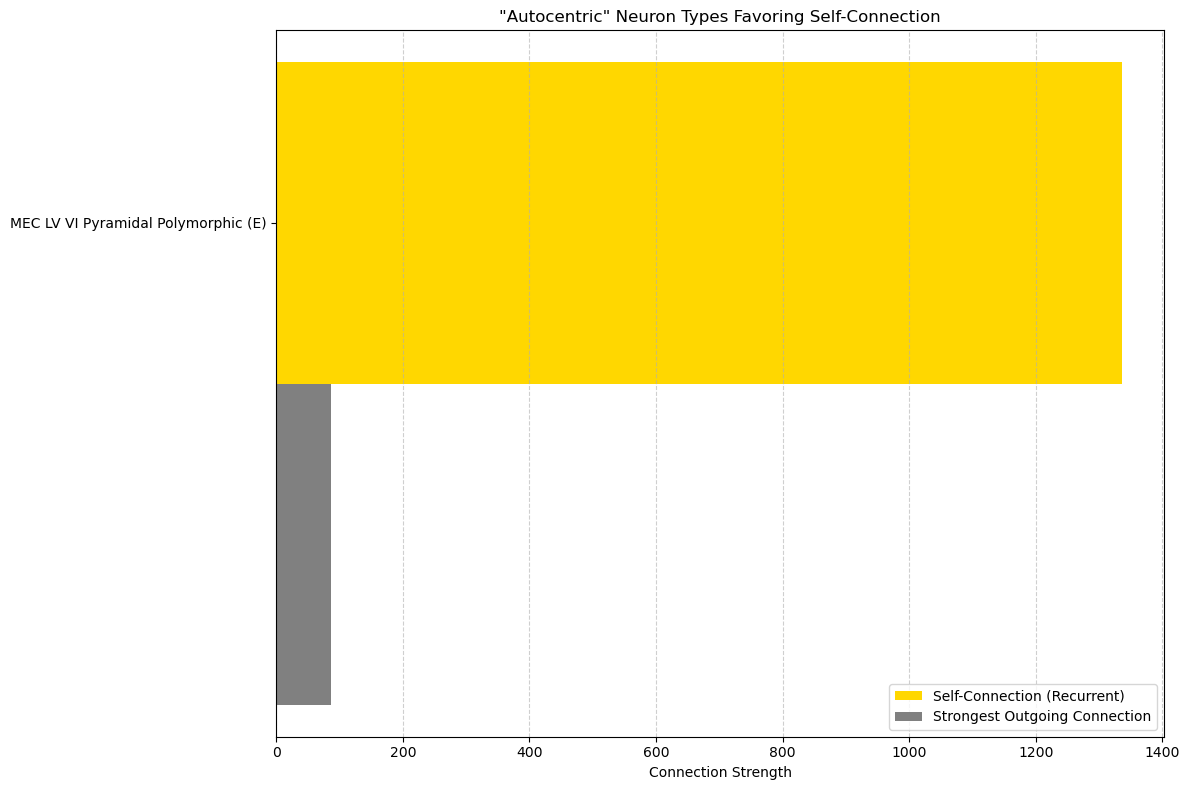

--- Autocentric Neuron Types ---
                                Neuron  Self-Connection  Max Outgoing
0  MEC LV VI Pyramidal Polymorphic (E)      1336.060086     86.775966


In [10]:
autocentric_df = find_autocentric_neurons(df_source_receiver)
plot_autocentric_neurons(autocentric_df)


Spectral radius ρ(M): 26213.130121 (not stable)
Peak ||M^k||₂: 1678914838182910426440814483110357543075538459238778451416457970022316329246634362219508359434276616186873771028729732080930052207547302888819280912979023811009970600343076625352900405990427726508221871830948270431732236288.000000 at k=50
Discrete Kreiss-style grid proxy: 3013.572988
Critical grid point: 668.7023 - 8693.1299i


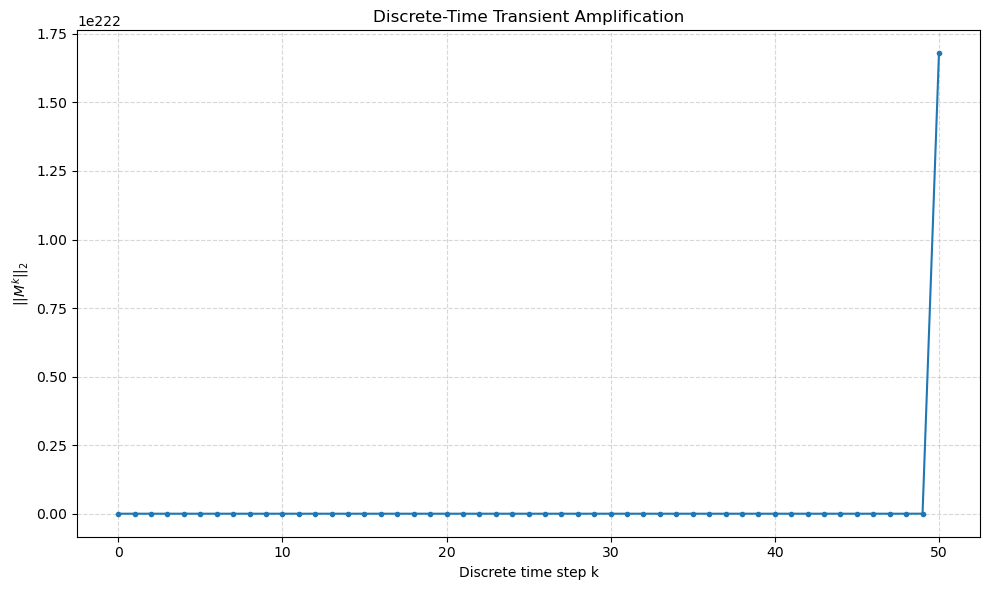

In [11]:
transient = analyze_discrete_transient_dynamics(M, k_max=50)
